# Github
https://github.com/WilliamKA02/CSS_Assignments

# Contributions
All members (William, Tobias & Laura) contributed equally to the assignment.

# Formalia

Please read the [assignment overview page](https://laura.alessandretti.com/comsocsci2026/wiki_pages/Assignments.html) carefully before proceeding. The page contains information about formatting (including formats etc), group sizes, and many other aspects of handing in the assignment. 

__If you fail to follow these simple instructions, it will negatively impact your grade!__

**Due date and time**: The assignment is due on Apr 7th at 23:59. Hand in your Jupyter notebook file (with extension `.ipynb`) via DTU Learn _(Assignment 2)_. 

Remember to include in the first cell of your notebook:
* the link to your group's Git repository 
* group members' contributions

In [2]:
import json, math, random, ast
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter, defaultdict


# Part 1: Mixing Patterns and Assortativity

__Exercise 1: Mixing Patterns and Assortativity__  

__Part 1: Assortativity Coefficient__ 
1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**

In [20]:
# Load CSS network
with open('../css_network.json') as f:
    data = json.load(f)
G_full = nx.node_link_graph(data)

# Filter to valid country, take LCC
valid = [n for n in G_full.nodes() if pd.notna(G_full.nodes[n].get('country'))]
G = G_full.subgraph(valid).copy()
G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f'GCC: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

GCC: 17222 nodes, 60387 edges


In [12]:
# Categorical assortativity by country
#   r = (Tr(e) - sum_i a_i^2) / (1 - sum_i a_i^2)
# e is symmetric for undirected graphs: each edge contributes to both e[i,j] and e[j,i], normalised by 2M.

def categorical_assortativity(G, attribute):
    attr = nx.get_node_attributes(G, attribute)
    types = sorted(set(attr.values()))
    idx = {t: i for i, t in enumerate(types)}
    K, M = len(types), G.number_of_edges()

    e = np.zeros((K, K))
    for u, v in G.edges():
        ci, cj = idx[attr[u]], idx[attr[v]]
        e[ci, cj] += 1
        e[cj, ci] += 1      # symmetric
    e /= (2 * M)            # sum(e) = 1

    a = e.sum(axis=1)
    return (np.trace(e) - np.sum(a**2)) / (1.0 - np.sum(a**2))

r_country = categorical_assortativity(G, 'country')
print(f'Country assortativity (manual):  {r_country:.6f}')
print(f'Country assortativity (NetworkX): {nx.attribute_assortativity_coefficient(G, "country"):.6f}')

Country assortativity (manual):  0.390506
Country assortativity (NetworkX): 0.390318


__Part 2: Configuration model__
In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  

2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:

  - **a.** Create an exact copy of your original network.
  - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
  - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
  - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
  - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
  - **f.** Repeat steps **b** to **e** until you have performed $E\cdot10$ swaps, where E is the total number of edges

In [13]:
def double_edge_swap(G_in, n_swaps=None):
    """Randomise an undirected graph via double edge swaps (preserves degree sequence)."""
    H = G_in.copy()
    edges = list(H.edges())
    M = len(edges)
    if n_swaps is None:
        n_swaps = 10 * M

    swaps_done, attempts = 0, 0
    max_attempts = 100 * n_swaps

    while swaps_done < n_swaps and attempts < max_attempts:
        attempts += 1
        i, j = random.sample(range(M), 2)
        u, v = edges[i]
        x, y = edges[j]

        # c. Flip e1 50% of the time — BEFORE validity checks
        if random.random() < 0.5:
            u, v = v, u

        # b/d. No self-loops, four distinct nodes, no multi-edges
        if u == y or x == v:
            continue
        if len({u, v, x, y}) < 4:
            continue
        if H.has_edge(u, y) or H.has_edge(x, v):
            continue

        # e. Perform the swap
        H.remove_edge(*edges[i])
        H.remove_edge(*edges[j])
        H.add_edge(u, y)
        H.add_edge(x, v)
        edges[i] = (u, y)
        edges[j] = (x, v)
        swaps_done += 1

    return H

 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.

In [ ]:
G_random = double_edge_swap(G)
print('Degree sequences identical:', sorted(dict(G.degree()).values()) == sorted(dict(G_random.degree()).values()))
print(f'Edges preserved: {G.number_of_edges()} - {G_random.number_of_edges()}')

Degree sequences identical: True
Edges preserved: 60387 -> 60387


 __Part 3: Analyzing Assortativity in Random Networks__  

 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.

  20/100
  40/100
  60/100
  80/100
  100/100


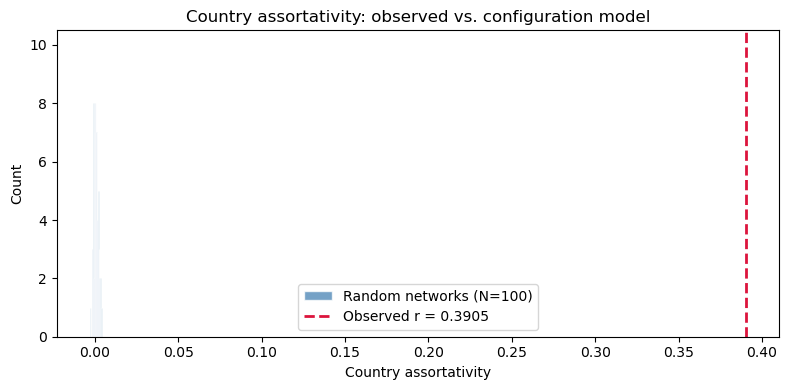

Observed r_country : 0.3905
Random mean +/- std: 0.0005 +/- 0.0015
Z-score            : 262.68


In [15]:
N_RAND = 100
r_rand_country = []

for i in range(N_RAND):
    H = double_edge_swap(G)
    r_rand_country.append(categorical_assortativity(H, 'country'))
    if (i+1) % 20 == 0: print(f'  {i+1}/{N_RAND}')

r_rand_country = np.array(r_rand_country)
z_country = (r_country - r_rand_country.mean()) / r_rand_country.std()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r_rand_country, bins=25, color='steelblue', alpha=0.75, edgecolor='white',
        label=f'Random networks (N={N_RAND})')
ax.axvline(r_country, color='crimson', lw=2, ls='--', label=f'Observed r = {r_country:.4f}')
ax.set_xlabel('Country assortativity'); ax.set_ylabel('Count')
ax.set_title('Country assortativity: observed vs. configuration model')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Observed r_country : {r_country:.4f}')
print(f'Random mean +/- std: {r_rand_country.mean():.4f} +/- {r_rand_country.std():.4f}')
print(f'Z-score            : {z_country:.2f}')

The observed country assortativity ($r \approx 0.39$) lies far to the right of the null distribution (random mean $\approx 0.0005$), giving a z-score of $\approx 263$. Within-country collaboration is overwhelmingly more common than expected by chance. This makes intuitive sense: geographic proximity, shared language, and national funding structures all promote co-authorship between scientists in the same country.

 __Part 4: Assortativity by Degree__

 5. *Calculate degree assortativity* for your network using the formula discussed in the lecture.

In [16]:
# Newman 2003 formula for undirected networks
def degree_assortativity(G):
    deg = dict(G.degree())
    M = G.number_of_edges()
    jk = np.array([(deg[u], deg[v]) for u, v in G.edges()])
    j, k = jk[:, 0], jk[:, 1]
    M_inv = 1.0 / M
    term1 = M_inv * np.sum(j * k)
    term2 = (M_inv * np.sum((j + k) / 2)) ** 2
    term3 = M_inv * np.sum((j**2 + k**2) / 2)
    return (term1 - term2) / (term3 - term2)

r_degree = degree_assortativity(G)
print(f'Degree assortativity (manual):  {r_degree:.6f}')
print(f'Degree assortativity (NetworkX): {nx.degree_assortativity_coefficient(G):.6f}')

Degree assortativity (manual):  -0.096306
Degree assortativity (NetworkX): -0.096779


 6. *Compare your network's degree assortativity* against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa.

  20/100
  40/100
  60/100
  80/100
  100/100


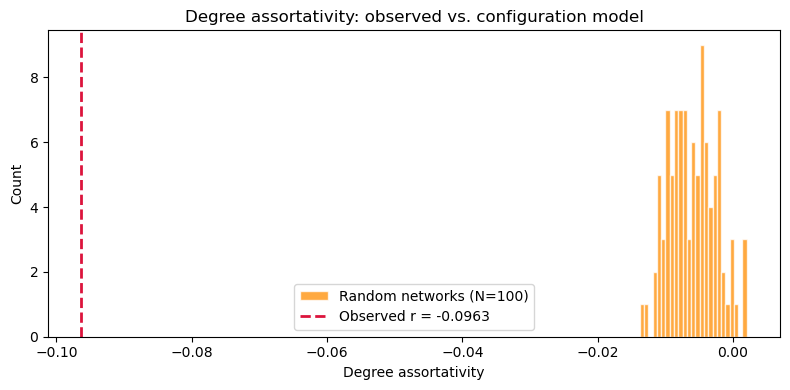

Observed r_degree : -0.0963
Random mean +/- std: -0.0060 +/- 0.0035
Z-score            : -26.14


In [17]:
r_rand_degree = []
for i in range(N_RAND):
    H = double_edge_swap(G)
    r_rand_degree.append(degree_assortativity(H))
    if (i+1) % 20 == 0: print(f'  {i+1}/{N_RAND}')

r_rand_degree = np.array(r_rand_degree)
z_degree = (r_degree - r_rand_degree.mean()) / r_rand_degree.std()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r_rand_degree, bins=25, color='darkorange', alpha=0.75, edgecolor='white',
        label=f'Random networks (N={N_RAND})')
ax.axvline(r_degree, color='crimson', lw=2, ls='--', label=f'Observed r = {r_degree:.4f}')
ax.set_xlabel('Degree assortativity'); ax.set_ylabel('Count')
ax.set_title('Degree assortativity: observed vs. configuration model')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Observed r_degree : {r_degree:.4f}')
print(f'Random mean +/- std: {r_rand_degree.mean():.4f} +/- {r_rand_degree.std():.4f}')
print(f'Z-score            : {z_degree:.2f}')

The network is significantly disassortative by degree: the observed $r \approx -0.096$ falls far below the configuration-model null (mean $\approx -0.006$, $z \approx -26$). High-degree scientists do not preferentially connect to other high-degree scientists — instead they tend to link to lower-degree colleagues.

 __Part 5: Reflection questions__

 7. *Assortativity by degree.* Were the results of the degree assortativity in line with your expectations? Why or why not?

This was somewhat surprising. We initially expected positive degree assortativity, assuming popular authors would preferentially collaborate with each other. However, co-authorship networks differ from typical social networks: a popular researcher has many collaborators who are individually less popular (PhD students, postdocs, etc.). Popular researchers simply have more opportunities to collaborate with a wide range of less-connected scientists than with the few other highly-connected ones. This probably happens because popular researchers collaborate a lot with their students and postdocs, who each have few collaborators themselves.

 8. *Edge flipping.* In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?

The edge-flipping step is included to remove directional bias introduced by how edges are constructed in the configuration model.

In an undirected graph, each edge is stored internally as an ordered tuple $(u, v)$ with a fixed but arbitrary ordering (typically $u < v$ by node ID). Without the flip, the swap always reconnects the first-listed endpoint of $e_1$ with the second-listed endpoint of $e_2$, and vice versa. This means the set of configurations reachable by swapping is restricted by the initial edge ordering — some valid rewirings can never occur.

By flipping $e_1$ with 50% probability, both endpoints are equally likely to be the one that gets reconnected. Without the flip, the swap always reconnects the same 'side' of each edge because of how tuples are ordered. Flipping randomly means both endpoints get a fair chance of being reconnected, so the randomisation isn't biased by how edges happen to be stored.

 9. *Distribution of assortativity in random networks.* Describe the distribution of degree assortativity values you observed for the random networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.

The null distribution is approximately normal, centered near $r \approx -0.006$ with a narrow spread ($\sigma \approx 0.004$). This is expected: the configuration model preserves the degree sequence but randomizes wiring, destroying systematic degree correlations. The near-zero mean confirms it is a valid null model. The slight negative bias is a well-known finite-size effect in networks with heterogeneous degree distributions: hubs must connect mostly to low-degree nodes because those dominate the population, and this bias vanishes as network size grows. The narrow width follows from the law of large numbers over ${\sim}60{,}000$ edges, and the edge-flipping step ensures unbiased sampling of the configuration space.

---
# Part 2: TF-IDF

 __Exercise 1: TF-IDF and the Computational Social Science communities.__ The goal for this exercise is to find the words charachterizing each of the communities of Computational Social Scientists.
 What you need for this exercise: 
.   
    * The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.  
    * the tokenized _abstract_ dataframe (Week 7, Exercise 2)

 1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF. 
   * What does TF stand for? 
   * What does IDF stand for?

TF-IDF stands for *term frequency – inverse document frequency*. It is a metric of how important a specific term is in a specific document within a larger corpus. The score is the product of two components:

**TF (Term Frequency)** is the frequency of term $t$ in document $d$:

$$\text{TF}(t,d) = \frac{\text{Count of } t \text{ in } d}{\text{Total number of terms in } d}$$

**IDF (Inverse Document Frequency)** down-weights terms that appear across many documents in the corpus. It's calculated by taking the logarithm of the inverse fraction of the documents containing the term $t$ across the enitre corpus $D$:

$$\text{IDF}(t,D) = \log\frac{\text{Total number of documents}}{\text{Number of documents containing } t}$$

And finally the TF-IDF is calculated by taking the product of these two metrics. This means the metric measures the importance of a term in a document by calculating how often the term appears in the document and scales it by how much rare the term is across all documents.

 2. Now, we want to find out which words are important for each *community*, so we're going to create several ***large documents, one for each community***. Each document includes all the tokens of abstracts written by members of a given community. 
   * Consider a community _c_
   * Find all the abstracts of papers written by a member of community _c_.
   * Create a long array that stores all the abstract tokens 
   * Repeat for all the communities. 
 __Note:__ Here, to ensure your code is efficient, you shall exploit ``pandas`` builtin functions, such as [``groupby.apply``](https://pandas.pydata.org/docs/reference/api/pandas.api.typing.DataFrameGroupBy.apply.html) or [``explode``](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html).

In [21]:
css_partition = {node: data['community'] for node, data in G.nodes(data=True)}
degree_dict = dict(G.degree())
comm_sizes = Counter(css_partition.values())
print(f'Communities: {len(set(css_partition.values()))}')

# Load tokenized abstracts and paper metadata
df_papers = pd.read_csv('../coauthor_papers.csv')
df_papers['author_ids'] = df_papers['author_ids'].apply(ast.literal_eval)
df_abstracts = pd.read_csv('../coauthor_abstracts_tokens.csv')
df_abstracts['tokens'] = df_abstracts['tokens'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else []
)

# one row per (paper, author)
df_ex = df_papers.explode('author_ids')
df_ex['author_id'] = df_ex['author_ids'].str.replace('https://openalex.org/', '', regex=False)
df_ex['community'] = df_ex['author_id'].map(css_partition)
df_ex = df_ex.dropna(subset=['community'])
df_ex['community'] = df_ex['community'].astype(int)

# Strip URL prefixes
df_ex['paper_id'] = df_ex['id'].str.replace('https://openalex.org/', '', regex=False)
df_abstracts['paper_id'] = df_abstracts['id'].str.replace('https://openalex.org/', '', regex=False)

# Deduplicate on (paper, community) meaning a paper with authors in communities 3 and 7 contributes tokens to both.
paper_comm = df_ex.drop_duplicates(subset=['paper_id', 'community'])[['paper_id', 'community']]
df_merged = df_abstracts.merge(paper_comm, on='paper_id', how='inner')

community_tokens = (
    df_merged[['community', 'tokens']].explode('tokens')
    .dropna(subset=['tokens']).groupby('community')['tokens'].apply(list)
)
print(f'Communities with documents: {len(community_tokens)}')

Communities: 92
Communities with documents: 86


 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the __top 5 communities__ (by number of authors). 

In [22]:
author_df = pd.DataFrame(list(css_partition.items()), columns=['author_id', 'community'])
top5_comms = author_df.groupby('community')['author_id'].count().sort_values(ascending=False).head(5).index.tolist()

def compute_tf(tokens):
    counts = Counter(tokens)
    total = len(tokens)
    return {w: c / total for w, c in counts.items()}

community_tf = {c: compute_tf(community_tokens[c]) for c in community_tokens.index}

print('Top 5 TF terms per community:')
for c in top5_comms:
    top5 = sorted(community_tf[c].items(), key=lambda x: x[1], reverse=True)[:5]
    print(f'  Community {c}: {[w for w, _ in top5]}')

Top 5 TF terms per community:
  Community 6: ['model', 'task', 'models', 'data', 'using']
  Community 13: ['model', 'method', 'image', 'features', 'images']
  Community 27: ['study', 'people', 'participants', 'research', 'group']
  Community 16: ['users', 'data', 'system', 'network', 'information']
  Community 5: ['model', 'network', 'networks', 'system', 'data']


   * Describe similarities and differences between the communities.
   * Why aren't the TFs not necessarily a good description of the communities?
   * Next, we calculate IDF for every word. 
   * What base logarithm did you use? Is that important?

**Similarities and differences:** The top-TF words are largely shared across communities — generic academic terms like *model*, *data*, *study*, *using* dominate everywhere. Where differences appear they are subtle: community 27 leans towards *people*, *participants*, *group* (social psychology), while community 13 features *image* and *features* (computer vision). But the overlap is too high for TF alone to distinguish communities.

**Why TF alone is not enough:** TF measures frequency *within* a single community but ignores whether a word is equally common across *all* communities. A term like *model* has high TF everywhere because it is generic academic vocabulary — it tells us nothing specific about any individual community. We need IDF to down-weight these terms shared across all communities.

**Log base:** We use the natural logarithm (`np.log`). The choice of base does not affect ranking — it only scales all IDF values by a constant factor. Since TF-IDF is used for ranking, the base is irrelevant.

In [23]:
N_docs = len(community_tokens)
doc_freq = Counter()
for tokens in community_tokens:
    doc_freq.update(set(tokens))

idf = {w: math.log(N_docs / doc_freq[w]) for w in doc_freq}
print(f'IDF computed for {len(idf):,} words across {N_docs} communities.')

IDF computed for 142,287 words across 86 communities.


 4. We're ready to calculate TF-IDF. Do that for the __top 9 communities__ (by number of authors). Then for each community: 
   * List the 10 top TF words 
   * List the 10 top TF-IDF words
   * List the top 3 authors (by degree)

In [24]:
community_tfidf = {
    c: {w: tf_val * idf[w] for w, tf_val in community_tf[c].items()}
    for c in community_tokens.index
}

top9_comms = author_df.groupby('community')['author_id'].count().sort_values(ascending=False).head(9).index.tolist()

def top_authors(comm, n=3):
    members = [nd for nd, c in css_partition.items() if c == comm]
    members = sorted(members, key=lambda x: -degree_dict.get(x, 0))[:n]
    return [(G.nodes[m].get('display_name', m), degree_dict.get(m, 0)) for m in members]

for c in top9_comms:
    # Top 10 TF words
    tf10 = sorted(community_tf[c].items(), key=lambda x: -x[1])[:10]
    # Top 10 TF-IDF words
    tfidf10 = sorted(community_tfidf[c].items(), key=lambda x: -x[1])[:10]
    # Top 3 authors by degree in this community
    authors = top_authors(c)
    print(f"\n{'='*60}")
    print(f'Community {c}  (top 3: {", ".join(n for n,_ in authors)})')
    print(f'  Top 10 TF      : {[w for w, _ in tf10]}')
    print(f'  Top 10 TF-IDF  : {[w for w, _ in tfidf10]}')


Community 6  (top 3: Dan Jurafsky, Michael S. Bernstein, Diyi Yang)
  Top 10 TF      : ['model', 'task', 'models', 'data', 'using', 'use', 'system', 'users', 'work', 'information']
  Top 10 TF-IDF  : ['qa', 'users', 'question_answering', 'machine_translation', 'semantic_parsing', 'wikipedia', 'natural_language', 'bleu', 'query', 'parsers']

Community 13  (top 3: Chunhua Shen, Bolei Zhou, Shuicheng Yan)
  Top 10 TF      : ['model', 'method', 'image', 'features', 'images', 'network', 'based', 'representation', 'methods', 'learning']
  Top 10 TF-IDF  : ['extensive_experiments', 'object_detection', 'action_recognition', 'image', 'discriminative', 'metric_learning', 'vqa', 'semantic_segmentation', 'video_representation', 'image_retrieval']

Community 27  (top 3: Nick Haslam, Matthew J. Hornsey, Hazel Rose Markus)
  Top 10 TF      : ['study', 'people', 'participants', 'research', 'group', 'effects', 'one', 'effect', 'behavior', 'model']
  Top 10 TF-IDF  : ['ingroup', 'intergroup', 'social_i

   * Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?

Yes, substantially. The TF top-10 lists are nearly identical across communities (generic words like *model*, *data*, *using*). The TF-IDF lists are distinct and interpretable — for example:
- Community 27 (social psychology): *ingroup*, *intergroup*, *social_identity*, *outgroup*, *prejudice*
- Community 13 (computer vision): *object_detection*, *action_recognition*, *semantic_segmentation*
- Community 0 (algorithmic game theory): *price_anarchy*, *auctions*, *mechanism_design*, *voting_rules*
- Community 20 (personality psychology): *personality*, *big_five*, *narcissism*

IDF assigns near-zero weight to words appearing in most of the 86 community documents and boosts words appearing in only a few. The product TF × IDF highlights words that are both frequent locally and rare globally.

__Exercise 2: The Wordcloud__. It's time to visualize our results!

 * Install the [`WordCloud`](https://pypi.org/project/wordcloud/) module. 
 * Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
 * Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration). 

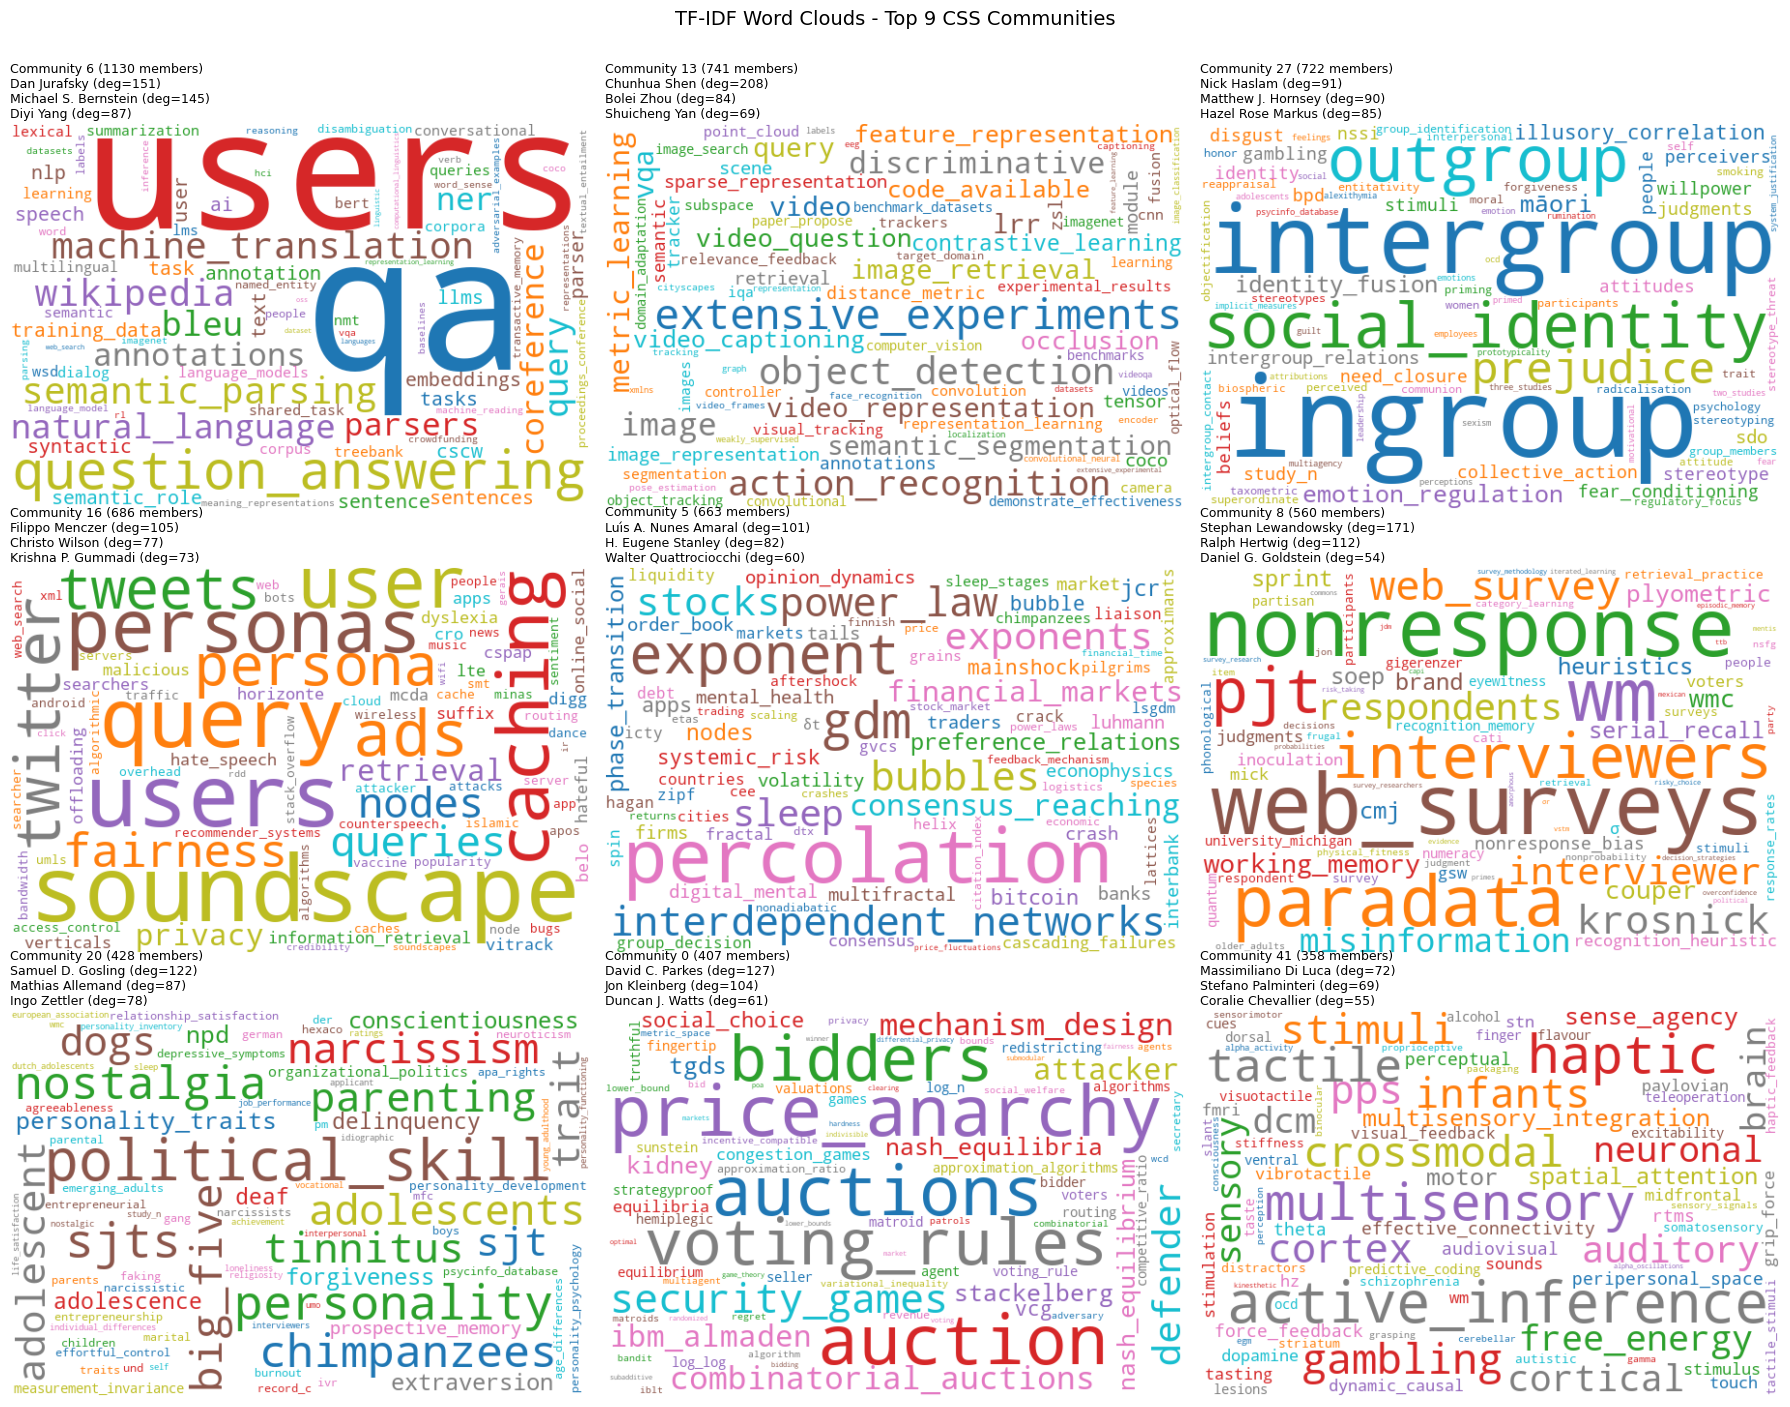

In [25]:
from wordcloud import WordCloud

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, c in zip(axes.flatten(), top9_comms):
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=80, colormap='tab10', prefer_horizontal=0.9
    ).generate_from_frequencies(community_tfidf[c])
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    authors = top_authors(c)
    ax.set_title(f'Community {c} ({comm_sizes[c]} members)\n'
                 + '\n'.join(f'{n} (deg={d})' for n, d in authors),
                 fontsize=9, loc='left', pad=4)
plt.suptitle('TF-IDF Word Clouds - Top 9 CSS Communities', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

 * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
 * Look up online the top author in each community. In light of your search, do your results make sense?


The nine largest communities map onto recognisable sub-disciplines:

| Community | Top authors | Characteristic TF-IDF terms | Sub-field |
|---|---|---|---|
| 6 | Dan Jurafsky, Michael Bernstein, Diyi Yang | *qa, question_answering, machine_translation, semantic_parsing* | NLP & human–computer interaction |
| 13 | Chunhua Shen, Bolei Zhou, Shuicheng Yan | *object_detection, action_recognition, semantic_segmentation, vqa* | Computer vision |
| 27 | Nick Haslam, Matthew Hornsey, Hazel Rose Markus | *ingroup, intergroup, social_identity, outgroup, prejudice* | Social psychology |
| 16 | Filippo Menczer, Christo Wilson, Krishna Gummadi | *soundscape, twitter, tweets, ads, personas* | Online platforms & social media |
| 5 | Luís Amaral, H. Eugene Stanley, Walter Quattrociocchi | *percolation, power_law, interdependent_networks, exponents* | Complex systems & statistical physics |
| 8 | Stephan Lewandowsky, Ralph Hertwig, Daniel Goldstein | *web_surveys, nonresponse, interviewers, respondents* | Survey methodology & decision science |
| 20 | Samuel Gosling, Mathias Allemand, Ingo Zettler | *personality, big_five, narcissism, nostalgia, chimpanzees* | Personality psychology |
| 0 | David Parkes, Jon Kleinberg, Duncan Watts | *price_anarchy, auctions, voting_rules, mechanism_design* | Algorithmic game theory |
| 41 | Massimiliano Di Luca, Stefano Palminteri, Coralie Chevallier | *active_inference, haptic, multisensory, tactile, crossmodal* | Perception & computational neuroscience |

**Author lookups confirm these labels.** 
- Dan Jurafsky co-authored the standard NLP textbook
- Chunhua Shen and Bolei Zhou are computer vision researchers
- Nick Haslam and Matthew Hornsey specialise in prejudice and intergroup relations
- Filippo Menczer is behind the social media observatory at Indiana University
- Luís Amaral and H. Eugene Stanley work on complex systems and scaling laws
- Ralph Hertwig studies decisions under uncertainty
- Samuel Gosling is known for Big Five personality research
- Jon Kleinberg and David Parkes work on algorithmic game theory and mechanism design
- Massimiliano Di Luca studies haptic perception and multisensory integration.

 __Exercise 3: Computational Social Science__ 

 * In light of your data-driven analysis, has your understanding of the field changed? How? 

Our understanding of the field has changed in two ways.

First, Computational Social Science is not a unified discipline, it's more like a collection of sub-fields that have adopted computational methods, each retaining its own vocabulary and questions. Social psychologists, computer vision researchers, NLP researchers, and political scientists all belong to the CSS co-authorship network, but the 92 detected communities show they rarely collaborate across these boundaries.

Second, simple methods are very powerfuly. TF-IDF applied to raw abstract tokens, combined with a co-authorship graph partition, gives community descriptions that match decades of expert knowledge about who works on what. Meaning we find a lot of structure simply in word frequencies, which is interesting.
